In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from functions import *

In [4]:
OWL_PATH1 = "data/oeo-full.owl"
OWL_PATH2 = "data/go-plus.owl"

In [7]:
base_cfg = BoxConfig(
    dim = 6,
    steps = 10000,
    seed = 42,
    size_weight = 0.1,
    subclass_weight = 5.0,
    disjoint_weight = 1.0,
    big_box_weight = 0.1,
    depth_scale = 0.5,
    distance_weight = 0.1)

In [8]:
schedule=CurriculumSchedule(
    subclass_start = 0.0,   # structural foundation first
    disjoint_start = 0.4,   # separation only after containment exists
    sibling_start = 0.5,
    big_box_start = 0.7,   # size control
    ramp = True
)

In [9]:
results_plain_oeo = sweep_dimensions(
    owl_path = OWL_PATH1,
    learn_fn = learn_boxes_from_owl,
    dims = range(2, 21),
    cfg = base_cfg,
    path = "saved1/plain_oeo",
)


Loading OWL: data/oeo-full.owl
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
Sweeping dims=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] | device=mps | noise=False | schedule=no
Training dim=2 with learn_boxes_from_owl
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/mo9728/dev/loss_function/.venv/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3701, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/dk/f009p3nx1dq_jsntz_ttvtxjp9r016/T/ipykernel_48129/2211279489.py", line 1, in <module>
    results_plain_oeo = sweep_dimensions(
                        ^^^^^^^^^^^^^^^^^
  File "/Users/mo9728/dev/loss_function/functions.py", line 832, in sweep_dimensions
    _, result = _train_one_dim((
                ^^^^^^^^^^^^^^^^
  File "/Users/mo9728/dev/loss_function/functions.py", line 750, in _train_one_dim
    result = learn_fn(**kwargs)
             ^^^^^^^^^^^^^^^^^^
  File "/Users/mo9728/dev/loss_function/functions.py", line 580, in learn_boxes_from_owl
    edges = OntologyEdges(classes, subclass_of, disjoint_pairs, device=device)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/mo9728/dev/loss_function/

In [89]:
results_curriculum_oeo = sweep_dimensions(
    owl_path = OWL_PATH1,
    learn_fn = learn_boxes_with_curriculum,
    schedule = schedule,
    dims = range(2, 21),
    cfg = base_cfg,
    path = "saved1/curr_oeo",
)

Loading OWL: data/oeo-full.owl
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
Sweeping dims=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] | device=mps | noise=False | schedule=yes
Training dim=2 with learn_boxes_with_curriculum
step  1000/10000 | loss=0.1221 | sub_viol=4 | dis_viol=4606 | avg_sib_dist=-11.1664
step  2000/10000 | loss=0.0661 | sub_viol=4 | dis_viol=4606 | avg_sib_dist=-15.5308
step  3000/10000 | loss=0.0509 | sub_viol=4 | dis_viol=4606 | avg_sib_dist=-17.9005
step  4000/10000 | loss=0.0453 | sub_viol=3 | dis_viol=4606 | avg_sib_dist=-19.6644
step  5000/10000 | loss=0.6816 | sub_viol=11 | dis_viol=1313 | avg_sib_dist=-12.0917
step  6000/10000 | loss=1.0278 | sub_viol=23 | dis_viol=1245 | avg_sib_dist=-13.8433
step  7000/10000 | loss=1.2974 | sub_viol=35 | dis_viol=1223 | avg_sib_dist=-14.9005
step  8000/10000 | loss=1.5696 | sub_viol=47 | dis_viol=1212 | avg_sib_dist=-12.8538
step  9000/10000 | loss=1.8063 | sub_vio

In [90]:
results_plain_oeo_noise = sweep_dimensions(
    owl_path = OWL_PATH1,
    learn_fn = learn_boxes_from_owl,
    dims = range(2, 21),
    cfg = base_cfg,
    noise = True,
    path = "saved1/plain_oeo_noise",
)

Loading OWL: data/oeo-full.owl
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
[NOISY] data/oeo-full.owl: 1565 classes | 1406 subclass | 63 disjoint
Sweeping dims=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] | device=mps | noise=True | schedule=no
Training dim=2 with learn_boxes_from_owl
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
[NOISY] data/oeo-full.owl: 1565 classes | 1406 subclass | 63 disjoint
step  1000/10000 | loss=0.3814 | sub_viol=4 | dis_viol=17 | avg_sib_dist=-7.8618
step  2000/10000 | loss=0.3001 | sub_viol=4 | dis_viol=5 | avg_sib_dist=-8.7720
step  3000/10000 | loss=0.2740 | sub_viol=4 | dis_viol=5 | avg_sib_dist=-9.1322
step  4000/10000 | loss=0.2619 | sub_viol=4 | dis_viol=1 | avg_sib_dist=-9.3149
step  5000/10000 | loss=0.2554 | sub_viol=4 | dis_viol=0 | avg_sib_dist=-9.4351
step  6000/10000 | loss=0.2517 | sub_viol=4 | dis_viol=0 | avg_sib_dist=-9.5063
step  7000/10000 | loss=

In [92]:
results_curriculum_oeo_noise = sweep_dimensions(
    owl_path = OWL_PATH1,
    learn_fn = learn_boxes_with_curriculum,
    schedule = schedule,
    dims = range(2, 21),
    cfg = base_cfg,
    noise = True,
    path = "saved1/curr_oeo_noise",
)

Loading OWL: data/oeo-full.owl
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
[NOISY] data/oeo-full.owl: 1565 classes | 1406 subclass | 63 disjoint
Sweeping dims=[2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20] | device=mps | noise=True | schedule=yes
Training dim=2 with learn_boxes_with_curriculum
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
[NOISY] data/oeo-full.owl: 1565 classes | 1406 subclass | 63 disjoint
step  1000/10000 | loss=0.1286 | sub_viol=4 | dis_viol=2665 | avg_sib_dist=-11.0170
step  2000/10000 | loss=0.0831 | sub_viol=4 | dis_viol=2665 | avg_sib_dist=-15.1538
step  3000/10000 | loss=0.0688 | sub_viol=3 | dis_viol=2665 | avg_sib_dist=-17.5182
step  4000/10000 | loss=0.0633 | sub_viol=4 | dis_viol=2665 | avg_sib_dist=-19.1962
step  5000/10000 | loss=0.0760 | sub_viol=4 | dis_viol=14 | avg_sib_dist=-15.2894
step  6000/10000 | loss=0.0669 | sub_viol=4 | dis_viol=3 | avg_sib_dist=-18.644

In [93]:
results_plain_go = sweep_dimensions(
    owl_path = OWL_PATH2,
    learn_fn = learn_boxes_from_owl,
    dims = range(5, 26),
    cfg = base_cfg,
    path = "saved1/plain_go",
)

Loading OWL: data/go-plus.owl
Loaded data/go-plus.owl: 84444 classes, 108200 subclass axioms, 656 disjoint pairs
Sweeping dims=[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] | device=mps | noise=False | schedule=no
Training dim=5 with learn_boxes_from_owl
step  1000/10000 | loss=0.8066 | sub_viol=3335 | dis_viol=4160 | avg_sib_dist=-6.4688
step  2000/10000 | loss=0.6407 | sub_viol=3128 | dis_viol=2655 | avg_sib_dist=-8.1599
step  3000/10000 | loss=0.5810 | sub_viol=2942 | dis_viol=1986 | avg_sib_dist=-9.1078
step  4000/10000 | loss=0.5492 | sub_viol=2686 | dis_viol=1684 | avg_sib_dist=-9.8137
step  5000/10000 | loss=0.5295 | sub_viol=2587 | dis_viol=1405 | avg_sib_dist=-10.3776
step  6000/10000 | loss=0.5167 | sub_viol=2584 | dis_viol=1186 | avg_sib_dist=-10.8737
step  7000/10000 | loss=0.5001 | sub_viol=2518 | dis_viol=812 | avg_sib_dist=-11.3394
step  8000/10000 | loss=0.4930 | sub_viol=2496 | dis_viol=672 | avg_sib_dist=-11.7566
step  9000/10000 | lo

KeyboardInterrupt: 

In [10]:
results_plain_go_noise = sweep_dimensions(
    owl_path = OWL_PATH2,
    learn_fn = learn_boxes_from_owl,
    dims = range(5, 26),
    cfg = base_cfg,
    noise = True,
    path = "saved1/plain_go_noise",
)

Loading OWL: data/go-plus.owl
Loaded data/go-plus.owl: 84444 classes, 108200 subclass axioms, 656 disjoint pairs
[NOISY] data/go-plus.owl: 84444 classes | 97400 subclass | 688 disjoint
Sweeping dims=[5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25] | device=mps | noise=True | schedule=no
Training dim=5 with learn_boxes_from_owl


KeyboardInterrupt: 

In [ ]:
results_curriculum_go = sweep_dimensions(
    owl_path = OWL_PATH2,
    learn_fn = learn_boxes_with_curriculum,
    schedule = schedule,
    dims = range(5, 26),
    cfg = base_cfg,
    path = "saved1/curr_go",
)

In [ ]:
results_curriculum_go_noise = sweep_dimensions(
    owl_path = OWL_PATH2,
    learn_fn = learn_boxes_with_curriculum,
    schedule = schedule,
    dims = range(5, 26),
    cfg = base_cfg,
    noise = True,
    path = "saved1/curr_go_noise",
)

careful how to call it, must use load_owl or load_owl_with errors accordingly!

In [69]:
classes, subclass_of, disjoint_pairs = load_owl(OWL_PATH1)
results_plain_oeo = load_sweep_results("saved1/plain_oeo", classes, subclass_of, disjoint_pairs)
results_curriculum_oeo = load_sweep_results("saved1/curr_oeo", classes, subclass_of, disjoint_pairs)

Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
Loaded 19 dimensions from saved/plain_oeo
Loaded 19 dimensions from saved/curr_oeo


In [70]:
classes, subclass_of, disjoint_pairs = load_owl_with_errors(OWL_PATH1)
results_plain_oeo_noise = load_sweep_results("saved1/plain_oeo_noise", classes, subclass_of, disjoint_pairs)
results_curriculum_oeo_noise = load_sweep_results("saved1/curr_oeo_noise", classes, subclass_of, disjoint_pairs)

Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
[NOISY] data/oeo-full.owl: 1565 classes | 1415 subclass | 63 disjoint
Loaded 19 dimensions from saved/plain_oeo_noise
Loaded 19 dimensions from saved/curr_oeo_noise


### eval

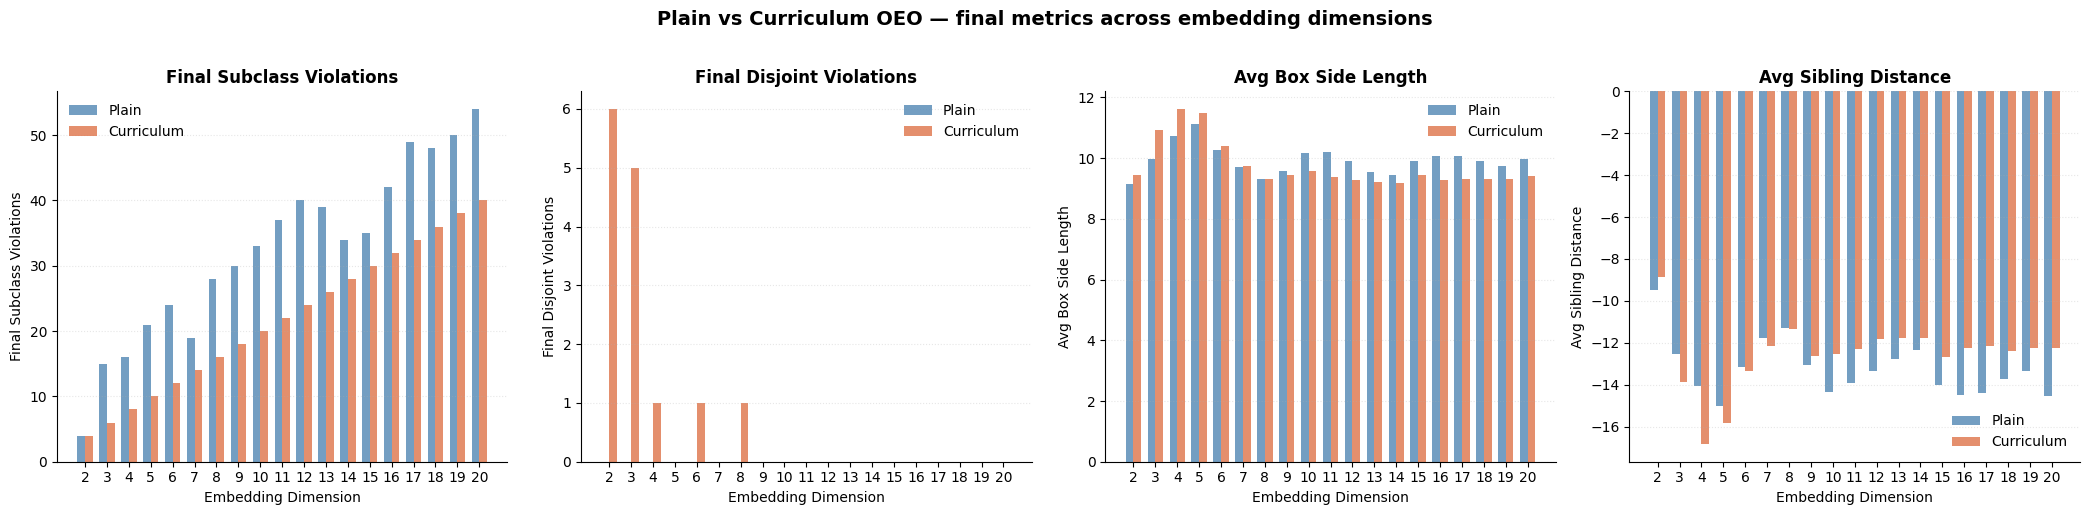

In [71]:
plot_sweep_comparison(results_plain_oeo, results_curriculum_oeo, "OEO")

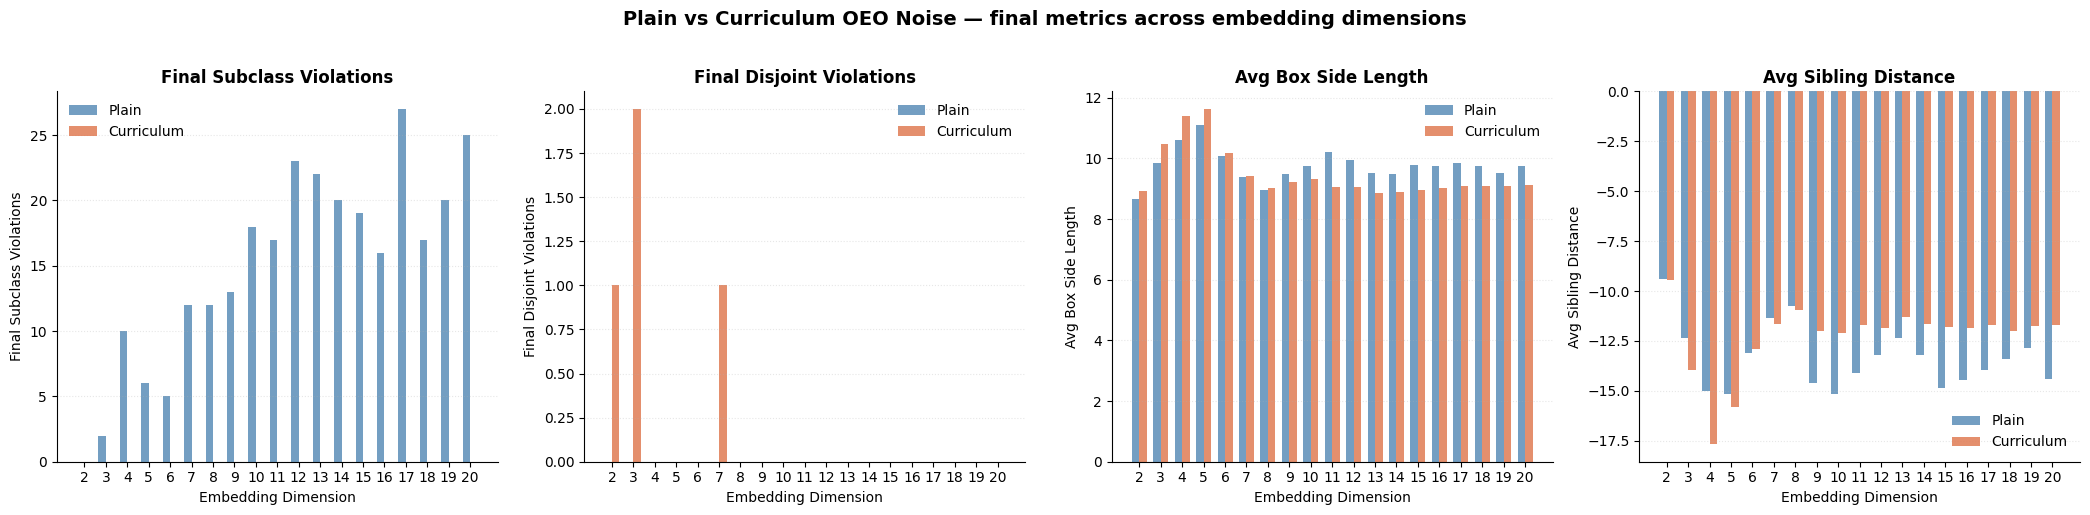

In [73]:
plot_sweep_comparison(results_plain_oeo_noise, results_curriculum_oeo_noise, "OEO Noise")

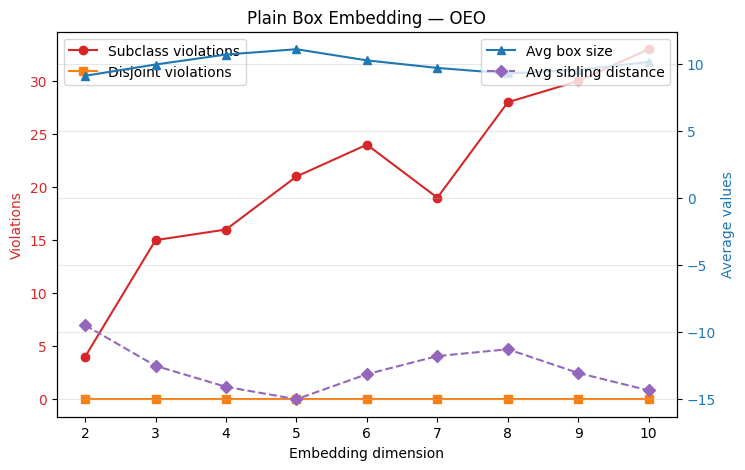

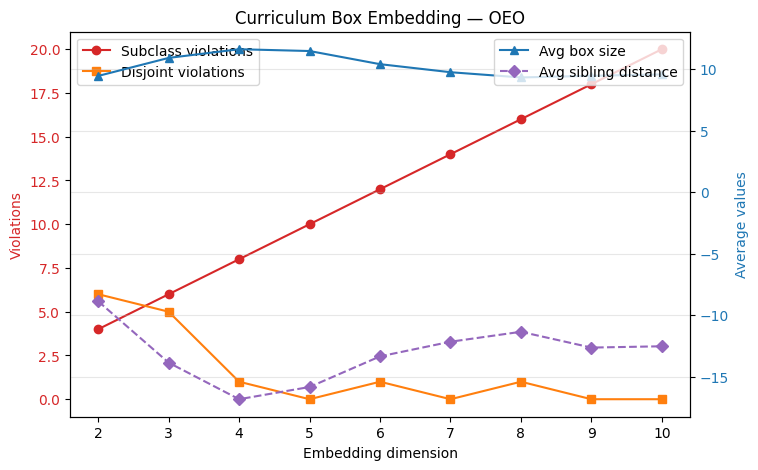

In [58]:
eval_plain_oeo = evaluate_models(results_plain_oeo)
plot_evaluation(eval_plain_oeo, title="Plain Box Embedding — OEO")

eval_curriculum_oeo = evaluate_models(results_curriculum_oeo)
plot_evaluation(eval_curriculum_oeo, title="Curriculum Box Embedding — OEO")


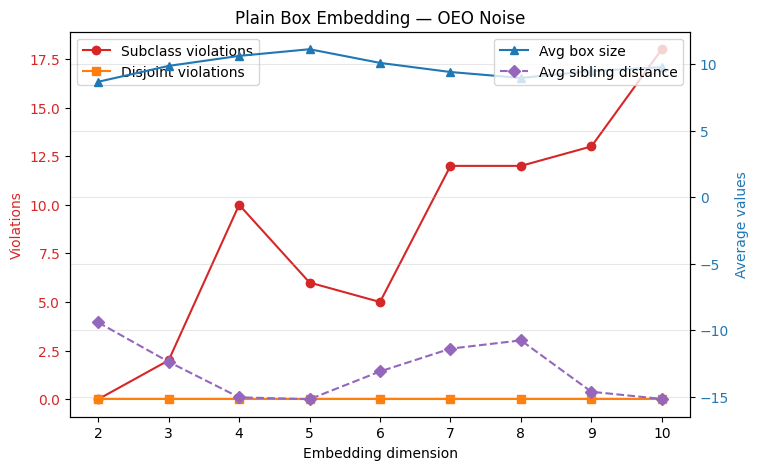

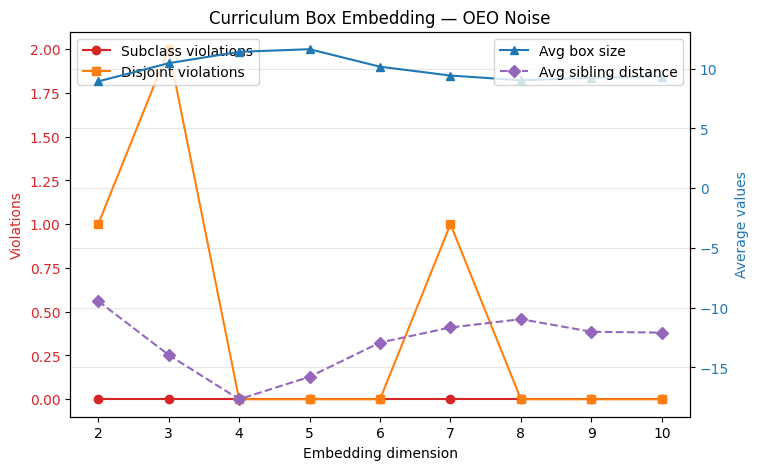

In [59]:
eval_plain_oeo_noise = evaluate_models(results_plain_oeo_noise)
plot_evaluation(eval_plain_oeo_noise, title="Plain Box Embedding — OEO Noise")

eval_curriculum_oeo_noise = evaluate_models(results_curriculum_oeo_noise)
plot_evaluation(eval_curriculum_oeo_noise, title="Curriculum Box Embedding — OEO Noise")


In [ ]:
eval_conc = evaluate_concluded_relationships(results_plain_oeo, disjoint_margin=0.05)
plot_concluded_evaluation(eval_conc, "OEO – Concluded Relationships (Plain)")

In [ ]:
eval_conc = evaluate_concluded_relationships(results_plain_oeo_noise, disjoint_margin=0.05)
plot_concluded_evaluation(eval_conc, "OEO – Concluded Relationships (Plain - Noise)")

In [ ]:
eval_conc_curr = evaluate_concluded_relationships(results_curriculum_oeo, disjoint_margin=0.05)
print(eval_conc_curr)
plot_concluded_evaluation(eval_conc_curr, "OEO – Concluded Relationships (Curriculum)")

In [ ]:
eval_conc_curr = evaluate_concluded_relationships(results_curriculum_oeo_noise, disjoint_margin=0.05)
plot_concluded_evaluation(eval_conc_curr, "OEO – Concluded Relationships (Curriculum Noise)")

In [ ]:
results = sweep_schedule_combinations(
    owl_path=OWL_PATH1,
    params={
        "disjoint_start" : [0.0, 0.5],
        "subclass_start" : [0.0, 0.5],
        "big_box_start"  : [0.0, 0.5],
        "sibling_start"  : [0.0, 0.5],
    },
    dim=4,
    steps=5000,
    base_schedule=CurriculumSchedule(ramp=True),
)
plot_combo_heatmaps(results)
plot_combo_lines(results, x_param="disjoint_start",
                 color_param="subclass_start", metric="sub_viol")

Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
step   100/1000 | loss=0.1724 | sub_viol=10 | dis_viol=193
step   200/1000 | loss=0.1833 | sub_viol=8 | dis_viol=52
step   300/1000 | loss=0.2119 | sub_viol=8 | dis_viol=21
step   400/1000 | loss=0.2528 | sub_viol=8 | dis_viol=14
step   500/1000 | loss=0.2947 | sub_viol=8 | dis_viol=5
step   600/1000 | loss=0.3425 | sub_viol=8 | dis_viol=3
step   700/1000 | loss=0.3917 | sub_viol=8 | dis_viol=2
step   800/1000 | loss=0.4418 | sub_viol=8 | dis_viol=2
step   900/1000 | loss=0.4924 | sub_viol=8 | dis_viol=2
step  1000/1000 | loss=0.5434 | sub_viol=8 | dis_viol=0
Done: {'disjoint_start': 0.0, 'subclass_start': 0.0, 'big_box_start': 0.0, 'sibling_start': 0.0, 'sub_viol': 8, 'dis_viol': 0, 'loss_final': None}
Loaded data/oeo-full.owl: 1565 classes, 1568 subclass axioms, 60 disjoint pairs
step   100/1000 | loss=0.3450 | sub_viol=29 | dis_viol=1145
step   200/1000 | loss=0.5736 | sub_viol=27 | dis_viol=989
step   3

/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  im = ax.imshow(
/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  im = ax.imshow(
/Users/mo9728/dev/loss-function/functions.py:1075: UserWarning: Attempting 

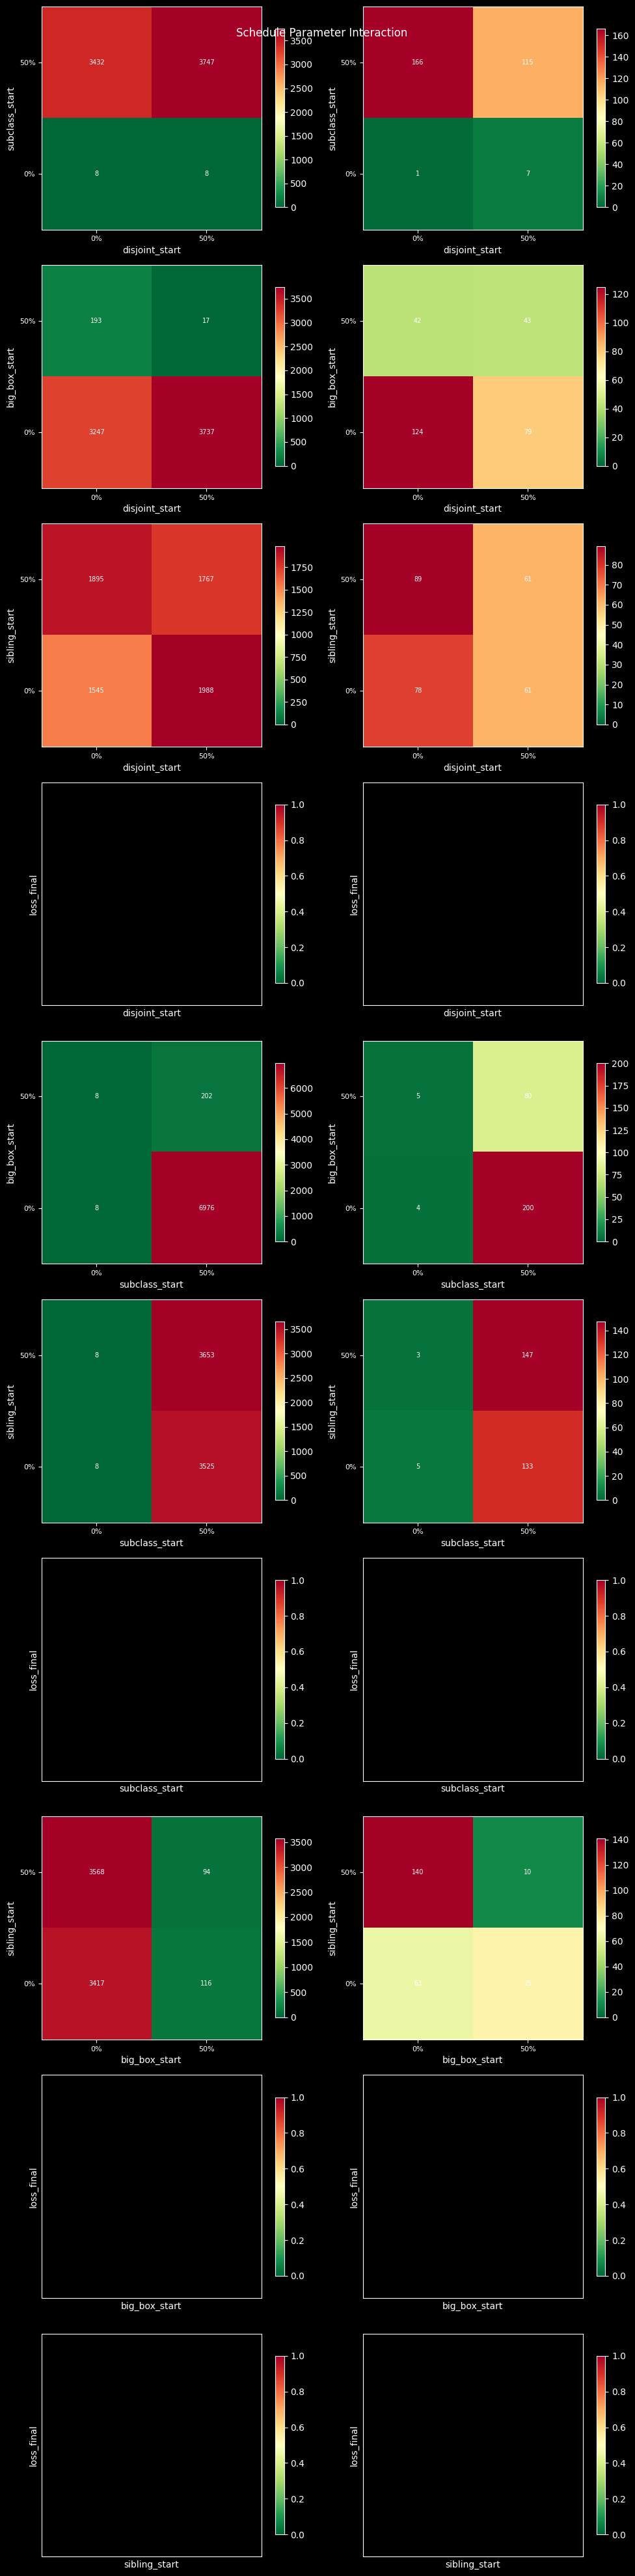

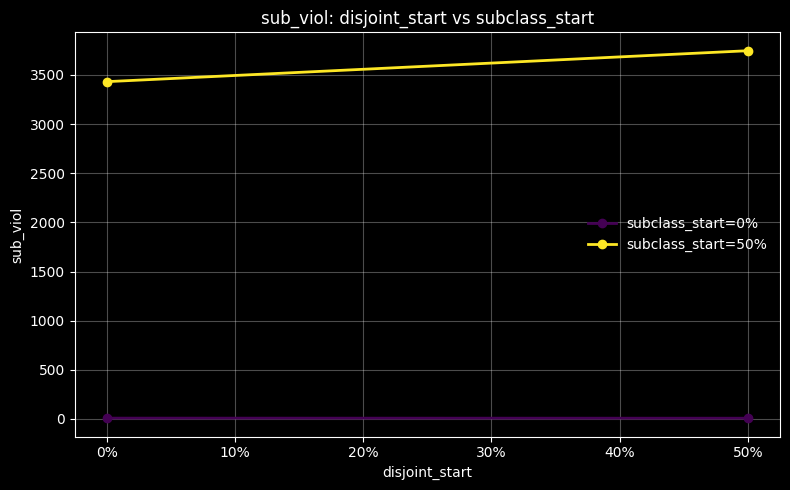

In [13]:
results = sweep_schedule_combinations(
    owl_path=OWL_PATH2,
    params={
        "disjoint_start" : [0.0, 0.5],
        "subclass_start" : [0.0, 0.5],
        "big_box_start"  : [0.0, 0.5],
        "sibling_start"  : [0.0, 0.5],
    },
    dim=4,
    steps=1000,
    base_schedule=CurriculumSchedule(ramp=True),
)
plot_combo_heatmaps(results, metrics=["sub_viol", "dis_viol", "loss_final", ""])
plot_combo_lines(results, x_param="disjoint_start",
                 color_param="subclass_start", metric="sub_viol")

In [ ]:
plot_all_starts_heatmap(results, title="All Start Parameters — Marginal Effects")